<a href="https://colab.research.google.com/github/rafli244/Tugas-Statistika-Rafli/blob/main/Tugas_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


         TABEL FREKUENSI GRADE          
╭─────────┬─────────────┬──────────────┬─────────────╮
│ Grade   │  Frekuensi  │ Persentase   │ Kumulatif   │
├─────────┼─────────────┼──────────────┼─────────────┤
│ A       │     13      │ 41.9%        │ 41.9%       │
├─────────┼─────────────┼──────────────┼─────────────┤
│ AB      │      7      │ 22.6%        │ 64.5%       │
├─────────┼─────────────┼──────────────┼─────────────┤
│ B       │      4      │ 12.9%        │ 77.4%       │
├─────────┼─────────────┼──────────────┼─────────────┤
│ BC      │      1      │ 3.2%         │ 80.6%       │
├─────────┼─────────────┼──────────────┼─────────────┤
│ C       │      5      │ 16.1%        │ 96.8%       │
├─────────┼─────────────┼──────────────┼─────────────┤
│ F       │      1      │ 3.2%         │ 100.0%      │
╰─────────┴─────────────┴──────────────┴─────────────╯


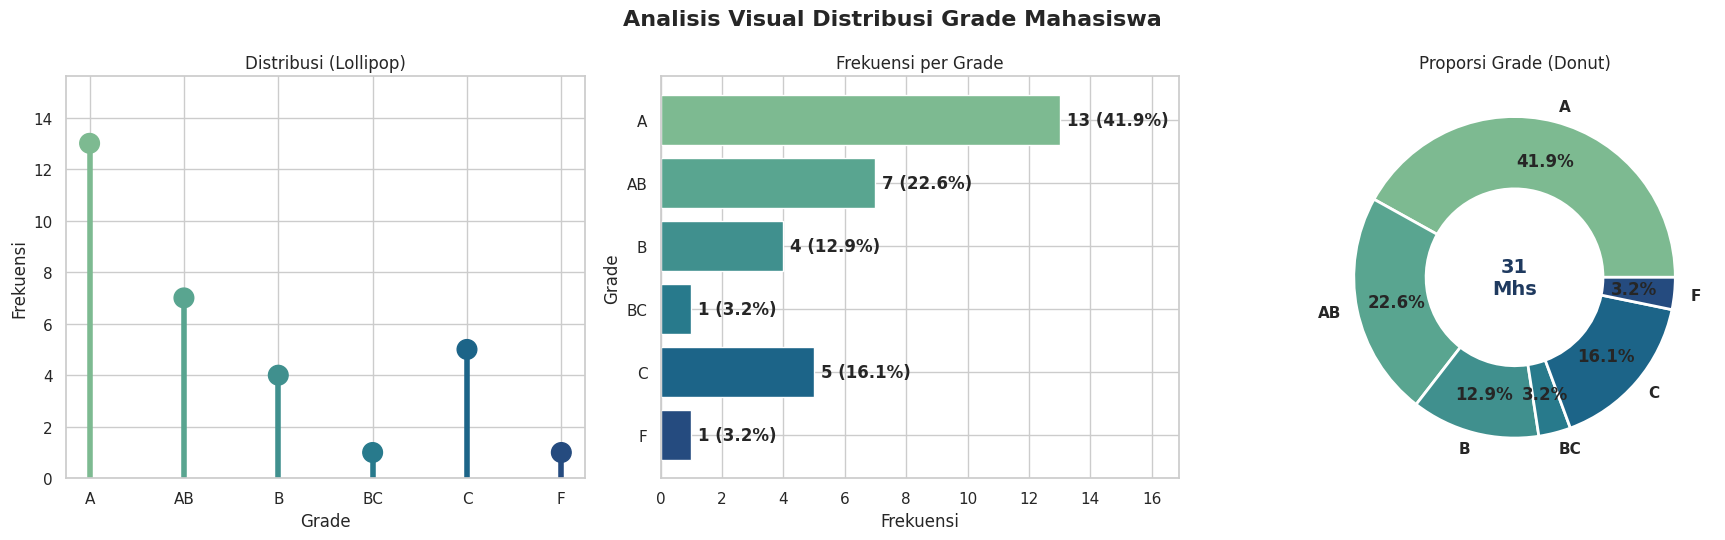


      STATISTIKA DESKRIPTIF NILAI       
╭────────────────┬───────────────────╮
│ Metrik         │   Nilai Statistik │
├────────────────┼───────────────────┤
│ count          │                31 │
├────────────────┼───────────────────┤
│ mean           │             76.49 │
├────────────────┼───────────────────┤
│ std            │             13.32 │
├────────────────┼───────────────────┤
│ min            │             46.01 │
├────────────────┼───────────────────┤
│ 25%            │              68.8 │
├────────────────┼───────────────────┤
│ 50%            │              79.3 │
├────────────────┼───────────────────┤
│ 75%            │             86.79 │
├────────────────┼───────────────────┤
│ max            │             94.03 │
├────────────────┼───────────────────┤
│ Standard Error │              2.39 │
├────────────────┼───────────────────┤
│ Median         │              79.3 │
├────────────────┼───────────────────┤
│ Modus          │              77.3 │
├────────────────┼────

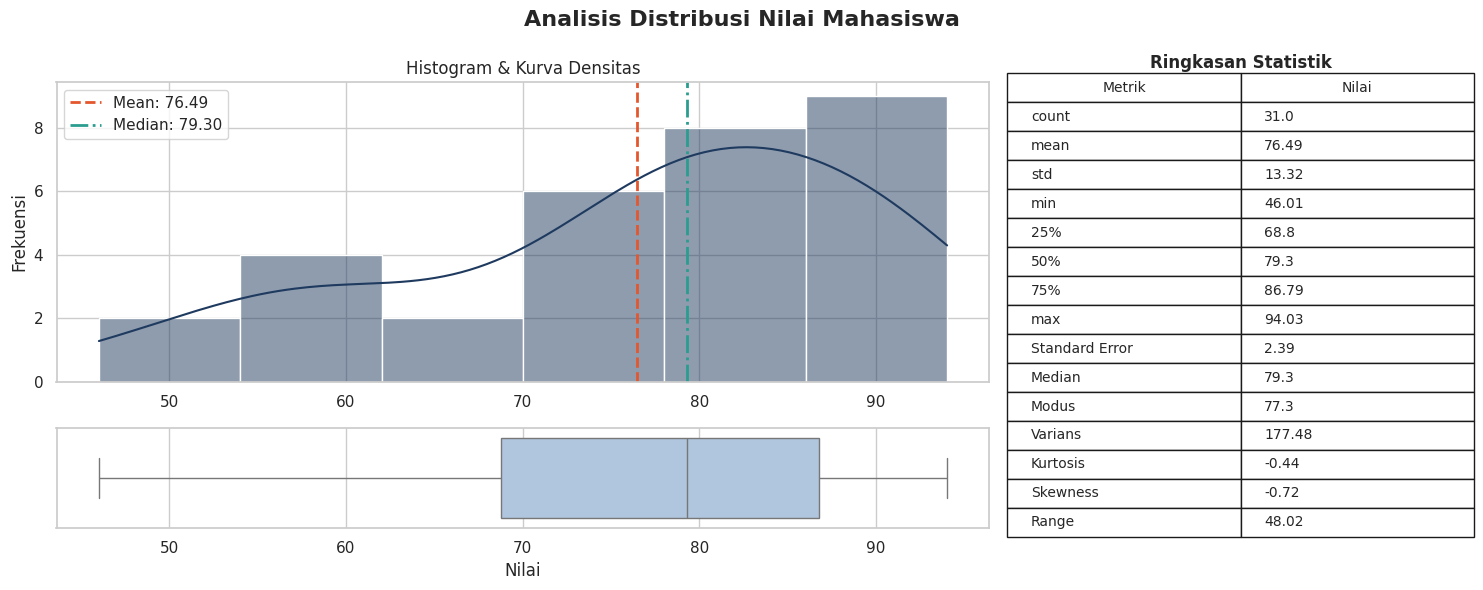

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from tabulate import tabulate

sns.set_theme(style="whitegrid", font="DejaVu Sans")
WARNA_UTAMA, WARNA_SOROT = "#1F3A5F", "#E4572E"

df = pd.read_excel(r"sample_data/Rafli.xlsx")
dt = pd.to_numeric(df["NILAI"], errors="coerce").dropna()
frek = df["Grade"].astype(str).str.strip().value_counts().sort_index()

persen = frek / frek.sum() * 100
df_frek = pd.DataFrame({
    "Frekuensi": frek,
    "Persentase": persen.map("{:.1f}%".format),
    "Kumulatif": persen.cumsum().map("{:.1f}%".format)
})
print(f"\n{'=' * 40}\n{'TABEL FREKUENSI GRADE'.center(40)}\n{'=' * 40}")
print(tabulate(df_frek, headers="keys", tablefmt="rounded_grid", numalign="center"))

fig1, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig1.suptitle("Analisis Visual Distribusi Grade Mahasiswa", fontsize=16, fontweight="bold")
warna_list = sns.color_palette("crest", len(frek))

axes[0].vlines(frek.index, 0, frek.values, colors=warna_list, linewidth=4)
axes[0].scatter(frek.index, frek.values, s=200, c=warna_list, zorder=3)
axes[0].set(title="Distribusi (Lollipop)", xlabel="Grade", ylabel="Frekuensi", ylim=(0, frek.max()*1.2))

bars = axes[1].barh(frek.index, frek.values, color=warna_list)
axes[1].bar_label(bars, labels=[f"{v} ({p:.1f}%)" for v, p in zip(frek, persen)], padding=5, fontweight="bold")
axes[1].set(title="Frekuensi per Grade", xlabel="Frekuensi", ylabel="Grade", xlim=(0, frek.max()*1.3))
axes[1].invert_yaxis()

axes[2].pie(frek, labels=frek.index, colors=warna_list, autopct='%1.1f%%', pctdistance=0.75,
            wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2), textprops={"fontweight": "bold"})
axes[2].text(0, 0, f"{frek.sum()}\nMhs", ha="center", va="center", fontsize=14, fontweight="bold", color=WARNA_UTAMA)
axes[2].set_title("Proporsi Grade (Donut)")

plt.tight_layout()
plt.savefig("distribusi_grade.png", dpi=300)
plt.show()

stats = dt.describe()
ekstra = pd.Series({
    "Standard Error": dt.sem(), "Median": dt.median(), "Modus": dt.mode().iloc[0],
    "Varians": dt.var(), "Kurtosis": dt.kurtosis(), "Skewness": dt.skew(), "Range": dt.max() - dt.min()
})
df_stats = pd.DataFrame(pd.concat([stats, ekstra]).round(2), columns=["Nilai Statistik"]).rename_axis("Metrik")

print(f"\n{'=' * 40}\n{'STATISTIKA DESKRIPTIF NILAI'.center(40)}\n{'=' * 40}")
print(tabulate(df_stats, headers="keys", tablefmt="rounded_grid", numalign="right"))

fig2 = plt.figure(figsize=(15, 6))
gs = GridSpec(2, 2, height_ratios=[3, 1], width_ratios=[2, 1])
ax_hist = fig2.add_subplot(gs[0, 0])
ax_box = fig2.add_subplot(gs[1, 0], sharex=ax_hist)
ax_tbl = fig2.add_subplot(gs[:, 1])
fig2.suptitle("Analisis Distribusi Nilai Mahasiswa", fontsize=16, fontweight="bold")

sns.histplot(dt, kde=True, color=WARNA_UTAMA, ax=ax_hist)
ax_hist.axvline(dt.mean(), color=WARNA_SOROT, ls="--", lw=2, label=f"Mean: {dt.mean():.2f}")
ax_hist.axvline(dt.median(), color="#2A9D8F", ls="-.", lw=2, label=f"Median: {dt.median():.2f}")
ax_hist.legend()
ax_hist.set(title="Histogram & Kurva Densitas", ylabel="Frekuensi", xlabel="")

sns.boxplot(x=dt, color="#A8C5E6", ax=ax_box)
ax_box.set(xlabel="Nilai")

ax_tbl.axis("off")
ax_tbl.set_title("Ringkasan Statistik", fontweight="bold", pad=10)
tbl = ax_tbl.table(cellText=df_stats.reset_index().values, colLabels=["Metrik", "Nilai"], loc="center", cellLoc="left")
tbl.scale(1, 1.8)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

plt.tight_layout()
plt.savefig("statistik_nilai.png", dpi=300)
plt.show()